## Logistic Regression 

This notebook is similar to an earlier logistic regression notebook and then goes into l1 and l2 penalities. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
import math
from IPython.display import Video

# Model imports
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Metrics imports
from sklearn import metrics
from sklearn.model_selection import train_test_split

### Load Data

The data we will use is the Breast Cancer Wisconsin (Diagnostic) Data Set: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic) which I converted to a csv for convenience. The goal of this prediction is successfully classifying cancer as malignant (1) or benign (0). 

In [2]:
df = pd.read_csv('data/wisconsinBreastCancer.csv')

In [3]:
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### Visualize Relationship between worst_concave_points and diagnosis

Text(0.5, 0, 'worst_concave_points')

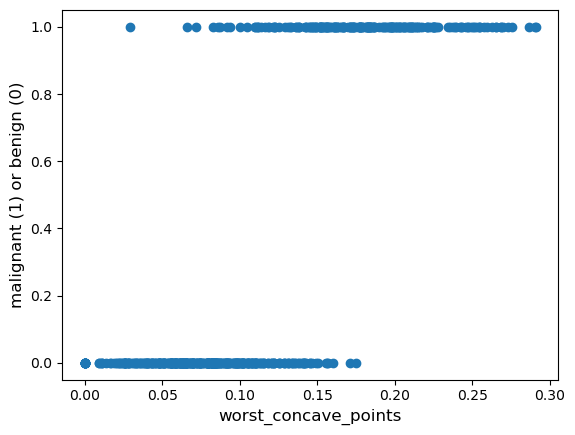

In [4]:
plt.scatter(df['worst_concave_points'], df['diagnosis'])
plt.ylabel('malignant (1) or benign (0)', fontsize = 12)
plt.xlabel('worst_concave_points', fontsize = 12)

### Exploring the name Logistic <b> Regression</b>
Linear regression was good when we wanted to predict a continuous value. This section is just showing trying using linear regression to classify and see where it falls short. malignant (1 in the graph above) or benign (0 in the graph below).

In [5]:
X = df['worst_concave_points'].values.reshape(-1,1)
y = df['diagnosis']

Text(0.5, 0, 'worst_concave_points')

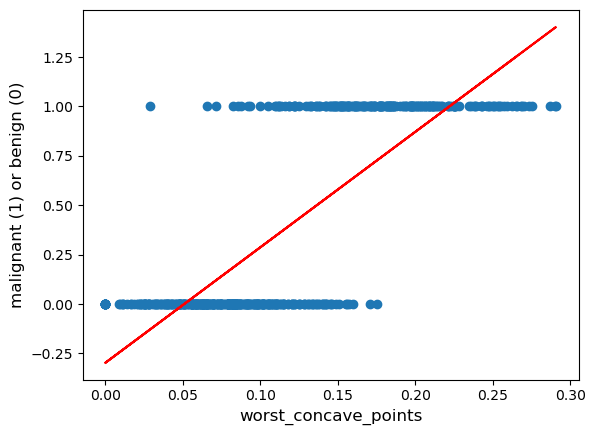

In [6]:
# Make a linear regression instance
lr = LinearRegression()

# Training the model on the data, storing the information learned from the data
# Model is learning the relationship between X and y 
lr.fit(X,y)

# Get Predictions for original x values
# This is not how we will do it for the rest of the course.
predictions = lr.predict(X)

plt.scatter(df['worst_concave_points'], df['diagnosis'])
plt.plot(df['worst_concave_points'], predictions, color='red')


plt.ylabel('malignant (1) or benign (0)', fontsize = 12)
plt.xlabel('worst_concave_points', fontsize = 12)

For now, around prediction value (red) >= 0.5 (around .15 for worst_concave_point), we predict a class of 1 (malignant), else we predict a class of 0 (benign).

Problem: If the value for worse_concave_points is .0, what does it mean when we have -.25 for our class instead of a 1 or zero? This seems odd. Maybe we should constrain our predictions between 0 and 1. 

### What is Logistic Regression
Linear regression: Continuous response is modeled as a linear combination of the features.

$$y = \beta_0 + \beta_1x$$

Logistic Regression: Bound output to 0 and 1. This will make logistic regression output the probabilities of a specific class. Probabilities can be converted into class predictions

$$y = \frac{1} {1 + e^{-(\beta_0 + \beta_1x)}}$$


This is graphed below

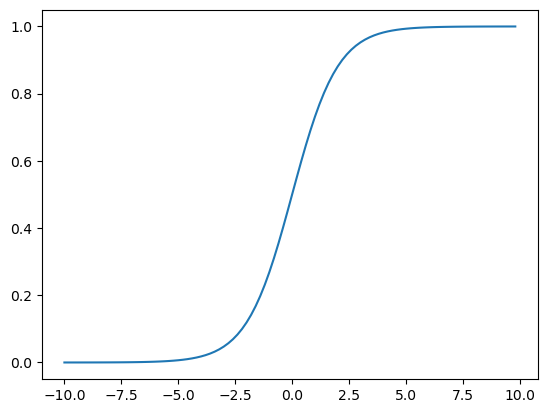

In [7]:
def sigmoid(x):
    a = []
    for item in x:
        a.append(1/(1+np.exp(-item)))
    return(a)

x = np.arange(-10., 10., 0.2)
sig = sigmoid(x)

plt.plot(x, sig)

## Showing Predictions for Logistic Regression

In [8]:
col_names = ['worst_concave_points']

X = df[col_names].values.reshape(-1,1)
y = df['diagnosis']

In [9]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)

In [10]:
# Standardize Data
scaler = StandardScaler()

# Fit on training set only.
scaler.fit(X_train)

# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
np.mean(X_train), np.std(X_train)

(np.float64(-1.918131798413416e-16), np.float64(1.0))

In [12]:
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |  
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |  
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted
 |  (and copied).
 |  
 |  The 'newton-cg', 'sag', and 'lbfgs' solvers s

In [13]:
# This C parameter is something we will cover!
# Keep in mind that there is l2 penalty by default like we have for ridge regression
logreg = LogisticRegression(C = 500000)

# Training the model on the data, storing the information learned from the data
# Model is learning the relationship between X and y 
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,500000
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [14]:
example_df = pd.DataFrame()
example_df.loc[:, 'worst_concave_points'] = X_train.reshape(-1)
example_df.loc[:, 'diagnosis'] = y_train.values

In [15]:
example_df.head()

,worst_concave_points,diagnosis
0,-0.364339,0
1,-1.450367,0
2,0.725046,1
3,-0.967772,0
4,-0.425826,1


Text(0.5, 0, 'worst_concave_points')

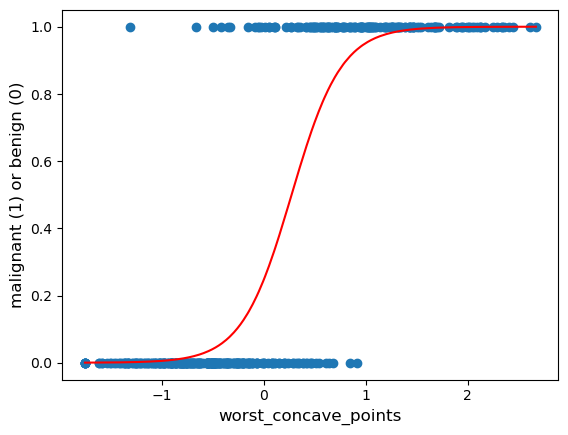

In [16]:
example_df['logistic_preds'] = pd.DataFrame(logreg.predict_proba(X_train))[1]
example_df = example_df.sort_values(['logistic_preds'])

plt.scatter(example_df['worst_concave_points'], example_df['diagnosis'])
plt.plot(example_df['worst_concave_points'], example_df['logistic_preds'].values, color='red')

plt.ylabel('malignant (1) or benign (0)', fontsize = 12)
plt.xlabel('worst_concave_points', fontsize = 12)

<b>Advantages of logistic regression:</b>

Able to interpret how the model makes predictions (if you know how)

Model training and prediction are relatively fast

No tuning is usually needed (excluding regularization)

Can perform well with a small number of observations

Outputs well-calibrated predicted probabilities

<b>Disadvantages of logistic regression:</b>

Presumes a linear relationship between the features and the log odds of the response

Performance is usually not competitive with the best supervised learning methods

### Interpreting Logistic Regression Coefficients

Logistic regression coefficients are not as immediately interpretable as the coefficients from a linear regression. To interpret the coefficients we need to remember how the formulation for logistic regression differs from linear regression.

Remember:

$$\log \left({p\over 1-p}\right) = \beta_0 + \beta_1x$$

That means we'll get out the log odds if we compute the intercept plus the coefficient times a value for `worse_concave_points`.

**Compute the log odds of `malignant` when `worse_concave_points=.6`.**

In [17]:
# Compute predicted log odds for worse_consave_points=.6 using the equation.
logodds = logreg.intercept_ + logreg.coef_[0] * .6
logodds

array([1.3417005])

Now that we have the log odds, we will need to go through the process of converting these log odds to probability.

**Convert the log odds to odds, then the odds to probability.**

In [18]:
# Convert log odds to odds.
odds = np.exp(logodds)
odds

array([3.8255433])

In [19]:
# Convert odds to probability.
prob = odds/(1 + odds)
prob

array([0.79276945])

This finally gives us the predicted probability of `malignant=1` when `worse_concave_points=.6`. You can confirm this is the same as the value you would get out of the `.predict_proba()` method of the scikit-learn object.

In [20]:
logreg.predict_proba(np.array([.6]).reshape(-1,1))

array([[0.20723055, 0.79276945]])

In [21]:
help(logreg.predict_proba)

Help on method predict_proba in module sklearn.linear_model._logistic:

predict_proba(X) method of sklearn.linear_model._logistic.LogisticRegression instance
    Probability estimates.
    
    The returned estimates for all classes are ordered by the
    label of classes.
    
    For a multi_class problem, if multi_class is set to be "multinomial"
    the softmax function is used to find the predicted probability of
    each class.
    Else use a one-vs-rest approach, i.e. calculate the probability
    of each class assuming it to be positive using the logistic function
    and normalize these values across all the classes.
    
    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Vector to be scored, where `n_samples` is the number of samples and
        `n_features` is the number of features.
    
    Returns
    -------
    T : array-like of shape (n_samples, n_classes)
        Returns the probability of the sample for each class in the model,


In [22]:
# Examine the coefficient for worse_concave_point.
list(zip(['worst_concave_points'], logreg.coef_[0]))

[('worst_concave_points', np.float64(4.078225530576946))]

In [23]:
# Print the intercept.
logreg.intercept_

array([-1.10523482])

**Interpretation:** A 1-unit increase in `worst_concave_points` is associated with a 4.082-unit increase in the log odds of `malignant`.

Keep in mind that all the values are normally fractional for the worse_concave_points. Try this on other columns

In [24]:
# Increasing worst_concave_points by 1 (so that worse_concave_point = 1.6)
logodds = -1.10588668 + 4.082113183653653*1.6
odds = np.exp(logodds)
prob = odds/(1 + odds)
prob

np.float64(0.9956164116774014)

**Bottom line:** Positive coefficients increase the log odds of the response (and thus increase the probability), and negative coefficients decrease the log odds of the response (and thus decrease the probability).

In [25]:
# Examine the intercept.
logreg.intercept_

array([-1.10523482])

**Intercept interpretation:** For an `worse_concave_points` value of 0, the log-odds of `malignant` is -1.10588668.

In [26]:
# Convert log odds to probability.
logodds = logreg.intercept_
odds = np.exp(logodds)
prob = odds/(1 + odds)
prob

array([0.24876033])

That makes sense from the plot above, because the probability of `malignant=1` should be very low for such a low `worse_concave_points` value.

![images](images/logistic_betas.png)

Changing the $\beta_0$ value shifts the curve horizontally, whereas changing the $\beta_1$ value changes the slope of the curve.

### Statistical Testing (for statisticians)

Logistic regression is one of the few machine learning models where we can obtain comprehensive statistics. By performing hypothesis testing, we can understand whether we have sufficient data to make strong conclusions about individual coefficients and the model as a whole. A very popular Python library which gives you these statistics with just a few lines of code is [statsmodels](http://www.statsmodels.org/dev/index.html).


### Power Analysis

As you may suspect, many factors affect how statistically significant the results of a logistic regression are. The art of estimating the sample size to detect an effect of a given size with a given degree of confidence is called power analysis.

Some factors that influence the accuracy of our resulting model are:

+ Desired statistical significance (p-value)
+ Magnitude of the effect
    - It is more difficult to distinguish a small effect from noise. So, more data would be required!
+ Measurement precision
+ Sampling error
    - An effect is more difficult to detect in a smaller sample.
+ Experimental design

So, many factors, in addition to the number of samples, contribute to the resulting statistical power. Hence, it is difficult to give an absolute number without a more comprehensive analysis. This analysis is out of the scope of this lesson, but it is important to understand some of the factors that affect confidence.

### Regularization

![images](images/C_parameter_chris_albon.png)

Looking at the effect of increasing C especially if you have `l1` regularization. Smaller values specify stronger regularization.

In [27]:
Video('images/effectOfCLogisticRegression.mp4',embed = True)

When C is tiny, you essentially have a model containing only the intercept. 

In [ ]:
# Same code was earlier in notebook, but here for clarity
# The rest of the lines in this sectionis just code I used to make the animation above

col_names = ['worst_concave_points']

X = df[col_names].values.reshape(-1,1)
y = df['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)

# Standardize Data
scaler = StandardScaler()

# Fit on training set only.
scaler.fit(X_train)

# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
for index,c in enumerate(np.linspace(-3, 3, num = 25)):
    
    c_value = 10**c
    c_value_str = "{0:0.3f}".format(c_value)
    # Keep in mind that there is l2 penalty by default like we have for ridge regression
    logreg = LogisticRegression(C = c_value)
    
    logreg.fit(X_train, y_train)

    example_df = pd.DataFrame()
    example_df.loc[:, 'worst_concave_points'] = X_train.reshape(-1)
    example_df.loc[:, 'diagnosis'] = y_train.values

    example_df['logistic_preds'] = pd.DataFrame(logreg.predict_proba(X_train))[1]
    example_df = example_df.sort_values(['logistic_preds'])

    plt.scatter(example_df['worst_concave_points'], example_df['diagnosis'])
    plt.plot(example_df['worst_concave_points'], example_df['logistic_preds'].values, color='red')

    plt.ylabel('malignant (1) or benign (0)', fontsize = 13)
    plt.xlabel('worst_concave_points', fontsize = 13)
    plt.title("Logistic Regression (L1) C = " + str(c_value_str), fontsize = 15)
    plt.savefig('imagesanimation/' + 'initial' + str(index).zfill(4) + '.png', dpi = 100)
    plt.cla()

In [ ]:
# If you are really curious, I can share how this works. 
# !ffmpeg -framerate 1 -i 'initial%04d.png' -c:v libx264 -r 30 -pix_fmt yuv420p initial_002.mp4

## Regularization and Effect on Accuracy

In [ ]:
help(LogisticRegression)

In [ ]:
col_names = ['worst_concave_points',
             'worst_perimeter',
             'mean_concave_points']

X = df[col_names].values
y = df['diagnosis']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)

In [ ]:
# Standardize Data
scaler = StandardScaler()

# Fit on training set only.
scaler.fit(X_train)

# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
np.linspace(-5, 5, num = 26)

In [ ]:
model_list, coef_list, reg_list, accuracy_list = [], [], [], []
for reg in np.linspace(-5, 5, num = 201):
    
    reg_value = 10**reg
    logreg = LogisticRegression(penalty = 'l1',
                                solver = 'saga',
                                
                                C = reg_value, 
                                max_iter = 100000)
    

    logreg.fit(X_train, y_train)
    model_list.append(logreg)
    accuracy_list.append(logreg.score(X_test, y_test))
    coef_list.append(logreg.coef_[0])
    reg_list.append(reg_value)

In [ ]:
coef_list[0]

In [ ]:
temp_df = pd.DataFrame(coef_list, index = reg_list, columns = col_names)

In [ ]:
temp_df.loc[:, 'model'] = model_list

In [ ]:
# Giving the index a name (it is not a column)
temp_df.index.name = 'C (Inverse of Regularization Strength)'

In [ ]:
temp_df.head()

In [ ]:
fig, axes = plt.subplots(nrows = 1, ncols = 1)

for column in col_names: 
    axes.plot(temp_df.index, temp_df.loc[:, column], label = column);

axes2=axes.twinx()
axes2.plot(temp_df.index, accuracy_list, color = 'r')
axes2.tick_params('y', colors='r');


coefLimits = temp_df.min().min(), temp_df.max().max() + .1
accuracyLimits = min(accuracy_list), max(accuracy_list) + .05

axes.set_ylim(coefLimits)
axes.set_yticks(np.linspace(coefLimits[0],coefLimits[1], 14))
axes.set_xscale('log')
axes.set_xlabel('C')
axes.set_ylabel('weights')
axes.set_title('Effect of Increasing Regularization')

axes2.set_ylim(accuracyLimits)
axes2.set_yticks(np.linspace(accuracyLimits[0],accuracyLimits[1], 14))
axes2.set_ylabel('Accuracy', color='r'); 

axes.grid();

axes.legend(loc=(1.2,.3),
            borderaxespad=0,
            fontsize = 10)

Notice how `worst_concave_points` takes longer to go to zero.It signals that i is the most important feature (for this method).

## Regularization and Effect on Accuracy (Animation)
Animation but only one Column

In [ ]:
Video('images/logisticRegularizationEffectAccuracy.mp4', width=640, height=360, embed = True)

In [ ]:
# Same code was earlier in notebook, but here for clarity

col_names = ['worst_concave_points']

X = df[col_names].values.reshape(-1,1)
y = df['diagnosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0)

# Standardize Data
scaler = StandardScaler()

# Fit on training set only.
scaler.fit(X_train)

# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model_list, coef_list, c_value_list, accuracy_list, example_df_list = [], [], [], [], []

for index,c in enumerate(np.linspace(-3, 3, num = 25)):
    
    c_value = 10**c
    c_value_str = "{0:0.3f}".format(c_value)
    # Keep in mind that there is l2 penalty by default like we have for ridge regression
    logreg = LogisticRegression(C = c_value,
                                penalty = 'l1',
                                solver = 'saga',
                                max_iter = 100000)
                                
    
    logreg.fit(X_train, y_train)
    
    # Subplot (top)
    example_df = pd.DataFrame()
    example_df.loc[:, 'worst_concave_points'] = X_train.reshape(-1)
    example_df.loc[:, 'diagnosis'] = y_train.values

    example_df['logistic_preds'] = pd.DataFrame(logreg.predict_proba(X_train))[1]
    example_df = example_df.sort_values(['logistic_preds'])
    example_df_list.append(example_df)
    model_list.append(logreg)
    accuracy_list.append(logreg.score(X_test, y_test))
    coef_list.append(logreg.coef_[0])
    c_value_list.append(c_value)
        
temp_df = pd.DataFrame(coef_list, index = c_value_list, columns = col_names)
    
temp_df.loc[:, 'model'] = model_list

# Giving the index a name (it is not a column)
temp_df.index.name = 'C (Inverse of Regularization Strength)'
    

In [ ]:
for index, (c_value,example_df) in enumerate(zip(c_value_list, example_df_list)):

    c_value_str = "{0:0.3f}".format(c_value)

    fig, axes = plt.subplots(nrows = 2,
                             ncols = 1,
                             figsize = (12, 7));

    # Just formatting, not relevant for this class
    fig.subplots_adjust(wspace=0.1, hspace = .55)

    """
    fig.suptitle("Logistic Regression (L1) C = " + str(c_value_str),
                 fontsize = 15,
                 y=.94)
    """

    # Code is just to make it so you have different colors in the "title"
    # https://stackoverflow.com/questions/9350171/figure-title-with-several-colors-in-matplotlib
    fig.text(0.45,
             0.92,
             "Logistic Regression (L1) C = ",
             ha="center",
             va="bottom",
             size=20,
             color="black")

    fig.text(0.68,
             0.92,
             str(c_value_str),
             ha="center",
             va="bottom",
             size=20,
             color="purple",)

    axes[0].scatter(example_df['worst_concave_points'], example_df['diagnosis'])
    axes[0].plot(example_df['worst_concave_points'], example_df['logistic_preds'].values, color='red')
    axes[0].set_ylabel('malignant (1) or benign (0)', fontsize = 13)
    axes[0].set_xlabel('worst_concave_points', fontsize = 11)

    axes[1].plot(temp_df.index,
                 temp_df.loc[:, 'worst_concave_points'],
                 label = 'worst_concave_points',
                 color = 'purple');
    
    axes[1].axvspan(c_value - c_value/10,c_value +  c_value/10, color='orange', alpha=0.3, zorder = 1);

    coefLimits = temp_df.min().min(), temp_df.max().max()
    accuracyLimits = min(accuracy_list), max(accuracy_list)
    
    axes[1].tick_params('y', colors='purple');
    axes[1].set_ylim(coefLimits)
    axes[1].set_yticks(np.linspace(coefLimits[0],coefLimits[1], 11))
    axes[1].set_xscale('log')
    axes[1].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axes[1].set_ylabel('weights', color='purple', fontsize = 13)
    axes[1].set_xlabel('C', fontsize = 11)

    axesTwin=axes[1].twinx()
    axesTwin.plot(temp_df.index, accuracy_list, color = 'g')
    axesTwin.tick_params('y', colors='g');
    axesTwin.set_ylim(accuracyLimits)
    axesTwin.set_yticks(np.linspace(accuracyLimits[0],accuracyLimits[1], 11))
    axesTwin.set_ylabel('Accuracy', color='g', fontsize = 13); 

    
    axes[1].grid();
    ###
    
    fig.savefig('imagesanimation2/' + 'initial' + str(index).zfill(4) + '.png', dpi = 100)

In [ ]:
# If you are really curious, I can share how this works. 
#!ffmpeg -framerate 1 -i 'initial%04d.png' -c:v libx264 -r 30 -pix_fmt yuv420p initial_002.mp4